In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [5]:
# Install Tesseract
!apt-get install tesseract-ocr -qq

# Install required libraries
!pip install pytesseract opencv-python pillow -q

# Verify installation
import pytesseract
import cv2
from PIL import Image

# Check Tesseract version
!tesseract --version

print("Tesseract installed!")

tesseract 4.1.1
 leptonica-1.82.0
  libgif 5.1.9 : libjpeg 8d (libjpeg-turbo 2.1.1) : libpng 1.6.37 : libtiff 4.3.0 : zlib 1.2.11 : libwebp 1.2.2 : libopenjp2 2.4.0
 Found AVX2
 Found AVX
 Found FMA
 Found SSE
 Found libarchive 3.6.0 zlib/1.2.11 liblzma/5.2.5 bz2lib/1.0.8 liblz4/1.9.3 libzstd/1.4.8
Tesseract installed!


In [6]:
# Step 3: Install EasyOCR
!pip install easyocr -q

import easyocr

# Initialize reader
reader = easyocr.Reader(['en'])

print("EasyOCR ready!")

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


EasyOCR ready!


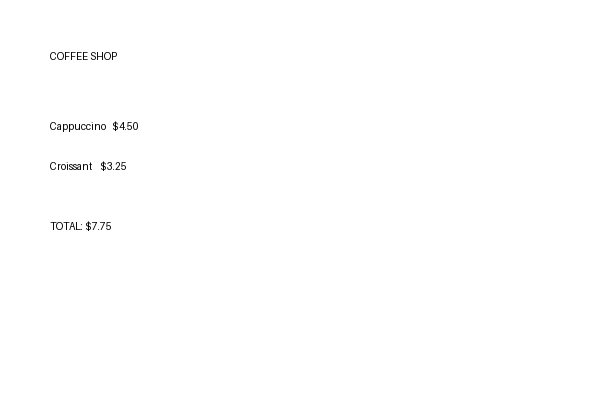

In [8]:
from PIL import Image, ImageDraw

img = Image.new('RGB', (600, 400), 'white')
draw = ImageDraw.Draw(img)

draw.text((50, 50), "COFFEE SHOP", fill="black")
draw.text((50, 120), "Cappuccino   $4.50", fill="black")
draw.text((50, 160), "Croissant    $3.25", fill="black")
draw.text((50, 220), "TOTAL: $7.75", fill="black")

img.save("receipt1.jpg")
img

In [9]:
import pytesseract
from PIL import Image

img = Image.open("receipt1.jpg")
text = pytesseract.image_to_string(img)

print(text)

COFFEE SHOP

Cappuccino $450,

Croisant $3.25

TOTAL $775



In [10]:
import easyocr

reader = easyocr.Reader(['en'])
result = reader.readtext("receipt1.jpg")

for r in result:
    print(r[1])

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


COFFEE SHOP
Cappuccino $4.50
Croissant
$3.25
TOTAL: $7.75


In [11]:
easy_text = " ".join([r[1] for r in result])

print("Tesseract length:", len(text))
print("EasyOCR length:", len(easy_text))

Tesseract length: 59
EasyOCR length: 57


In [13]:
for i in range(3):
    img = Image.new('RGB', (600, 400), 'white')
    draw = ImageDraw.Draw(img)

    draw.text((50, 50), f"SHOP {i+1}", fill="black")
    draw.text((50, 120), "Item A  $5", fill="black")
    draw.text((50, 160), "Item B  $3", fill="black")
    draw.text((50, 220), "TOTAL: $8", fill="black")

    img.save(f"receipt_{i}.jpg")

print("3 receipts created!")

3 receipts created!


In [15]:
import cv2
from PIL import Image

img = cv2.imread("receipt1.jpg")

In [16]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [18]:
blur = cv2.GaussianBlur(gray, (5,5), 0)

In [19]:
_, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)

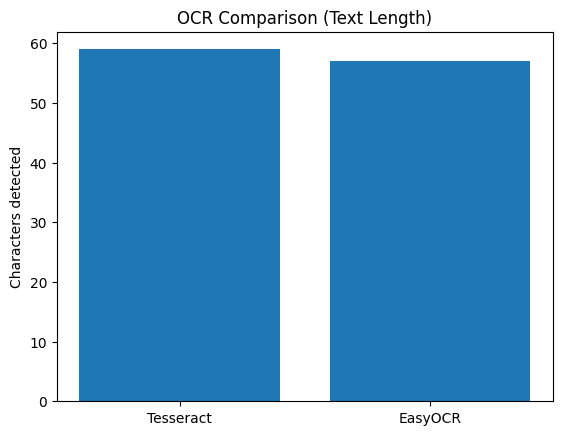

In [25]:
import matplotlib.pyplot as plt

methods = ["Tesseract", "EasyOCR"]
lengths = [59, 57]   # tumhare output values

plt.bar(methods, lengths)
plt.title("OCR Comparison (Text Length)")
plt.ylabel("Characters detected")

plt.show()

In [21]:
import pytesseract
from PIL import Image

text_clean = pytesseract.image_to_string(thresh)

print("=== CLEAN OCR OUTPUT ===")
print(text_clean)

=== CLEAN OCR OUTPUT ===



In [22]:
import easyocr

reader = easyocr.Reader(['en'])
result = reader.readtext("receipt1.jpg")

print("=== EASYOCR OUTPUT ===")
for r in result:
    print(r[1])

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


=== EASYOCR OUTPUT ===
COFFEE SHOP
Cappuccino $4.50
Croissant
$3.25
TOTAL: $7.75


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [23]:
easy_text = " ".join([r[1] for r in result])

print("Original Tesseract:", len(text))
print("Cleaned Tesseract:", len(text_clean))
print("EasyOCR:", len(easy_text))

Original Tesseract: 59
Cleaned Tesseract: 1
EasyOCR: 57
